# spikeinterface_pipeline

**A spike sorting pipeline for extracellular electrophysiology, built on [SpikeInterface](https://spikeinterface.readthedocs.io/).** One notebook for SpikeGLX, Open Ephys, and Multi-Channel Systems (MCS) recordings.

Edit the first two cells (format, paths, parameters), then **Kernel → Restart & Run All**. Everything else runs on its own, and all outputs land in `base_folder/`.

---

## Setup

The only two cells you need to edit before running. All other cells execute automatically.

---

**Cell 2 — format & paths**

- `FORMAT` — set to `'spikeglx'`, `'openephys'`, or `'mcs'` to match your recording system.
- Data path — only the variable matching your `FORMAT` is used (`spikeglx_folder`, `openephys_folder`, or `mcs_file`); the others are ignored.
- `base_folder` — where all outputs are saved: preprocessed recording, sorter results, quality metrics, and the analyzer. Created automatically if it doesn’t exist.

---

**Cell 3 — parameters**

*Format-specific (inside the `if FORMAT ==` block for your format):*

- `freq_min` — highpass filter cutoff in Hz. 
- `sorter` — which spike sorter to run. Options are listed in the inline comment.
- `stream_name` — SpikeGLX and OpenEphys only. Identifies which data stream to load. 
- `use_raw` — MCS only. `False` reads the `.h5` file exported from Multi Channel DataManager (recommended); `True` reads a raw binary, which requires a separate header file.
- `cref_operator` / `cref_reference` — common-reference settings. `median` is more robust than `mean` when some channels are noisy. `local` subtracts a neighbourhood average (good for dense probes); `global` subtracts across all channels.

*Probe geometry:*

- `manual_probe_file` — path to a geometry file if your recording doesn’t have one embedded. SpikeGLX always embeds geometry so leave this `None`; MCS and OpenEphys usually need it. Supported formats: `.json`, `.prb`, `.csv`, `.npy`.
- `dummy_probe_type` — fallback used only when no geometry is available. `'grid'` suits MEA arrays, `'tetrode'` suits tetrode recordings, `'linear'` is default and works with all sorters considering the channel spatially independent.
- `channel_label_csv` — optional CSV (`channel_id`, `electrode_label` columns) to rename channels before sorting. Useful when the physical wiring doesn’t match channel order. Leave `None` to keep original IDs.

*Common settings:*

- `test_duration_s` — clip the recording to N seconds for a quick test run. Set to `None` to process the full recording.
- `waveform_ms_before` / `waveform_ms_after` — how much signal to extract around each spike peak for waveform snippets and template computation.
- `max_spikes_per_unit` — how many randomly sampled spikes per unit are used for waveforms and metrics. Lower values speed things up.
- `compute_pca_metrics` — set to `False` to skip PCA-based metrics and speed up the analysis.

*Quality filtering thresholds (units failing any are discarded):*

- `amplitude_cutoff_thresh` — max estimated fraction of spikes cut off by the detection threshold.
- `isi_violations_ratio_thresh` — max refractory-period violation ratio.
- `presence_ratio_thresh` — minimum fraction of the recording in which the unit must be active. 

In [1]:
import spikeinterface.full as si
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

In [2]:
# SET FORMAT AND FILE PATHS  (edit this cell)

# FORMAT
FORMAT = 'openephys'   # 'spikeglx' | 'openephys' | 'mcs'

# PATHS
spikeglx_folder  = Path(r'C:\Users\labuser\Ilaria\data_for_Ilaria\2977_20250510\2977_20250510_g0\2977_20250510_g0_imec0')
openephys_folder = Path(r'C:\Users\labuser\Downloads\data for Ilaria\data for Ilaria\2023_09_13\2023-09-13_12-40-06_W3P12_first_piece_Pos2')
mcs_file         = Path(r'C:\Users\labuser\Ilaria\Data\C5\C5_output\2026-03-27T11-17-48McsRecording_E-00218.h5')

# OUTPUT FOLDER
# The folder is created automatically if it does not exist.
if FORMAT == 'spikeglx':
    base_folder = Path(r'C:\Users\labuser\Ilaria\spikeinterface_pipeline\output\spikeglx\2977_20250510_output')
elif FORMAT == 'openephys':
    base_folder = Path(r'C:\Users\labuser\Ilaria\spikeinterface_pipeline\output\openephys\openephys_output_2min')
elif FORMAT == 'mcs':
    base_folder = Path(r'C:\Users\labuser\Ilaria\spikeinterface_pipeline\output\mcs\mcs_tutorial_output_3min')
else:
    raise ValueError(f"Unknown FORMAT '{FORMAT}'. Choose 'spikeglx', 'openephys', or 'mcs'.")

base_folder.mkdir(parents=True, exist_ok=True)

In [3]:
# CHECK AND ADJUST PARAMETERS  (edit this cell)
# All other cells run automatically

# FORMAT-SPECIFIC PARAMETERS

if FORMAT == 'mcs':
    use_raw  = False       # False = read MCS .h5 export (recommended); True = raw binary (needs a separate header file)
    freq_min = 200.        # highpass cutoff (Hz)
        
    sorter   = 'mountainsort5'   # 'herdingspikes' | 'tridesclous2' | 'spykingcircus2' | 'mountainsort5' | 'kilosort4'
    cref_operator  = 'median'    # 'median' (robust to noisy/bad channels) | 'mean'
    cref_reference = 'local'     # 'local' (subtracts local neighbourhood average) | 'global' (subtracts across all channels)
    _analyzer_sparse = False
    _source_path = str(mcs_file)

elif FORMAT == 'openephys':
    stream_name = 'Record Node 101#Acquisition_Board-100.Rhythm Data'
    # Not sure of your stream name? Uncomment the line below, run this cell, then re-comment it:
    # print(si.get_neo_streams('openephysbinary', openephys_folder))
    freq_min = 300.         
    sorter   = 'tridesclous2'      # 'herdingspikes' | 'tridesclous2' | 'spykingcircus2' | 'mountainsort5' | 'kilosort4'
    cref_operator  = 'median'
    cref_reference = 'global'
    _analyzer_sparse = False
    _source_path = str(openephys_folder)
    # TTL-triggered artifact removal (disabled by default, uncomment to use)
    # use_ttl_artifacts = False
    # ttl_channel_id    = 'Rhythm FPGA TTL Input'

elif FORMAT == 'spikeglx':
    stream_name = 'imec0.ap'       # AP-band stream; change to 'imec1.ap' etc. for other probes
    freq_min = 400.          
    sorter   = 'kilosort4'        # 'herdingspikes' | 'tridesclous2' | 'spykingcircus2' | 'mountainsort5' | 'kilosort4'
    cref_operator  = 'median'
    cref_reference = 'global'
    _analyzer_sparse = True        
    _source_path = str(spikeglx_folder)

# PROBE MAP
# Path to a probe geometry file. Leave as None if geometry is already embedded in the file.
# Supported formats:
#   .json  native probeinterface — full geometry + wiring
#   .prb   klusta/spyking-circus legacy — geometry + wiring
#   .csv   two-column (x, y) position table, rows must match channel order
#   .npy   (n_channels, 2) numpy array of (x, y) positions in µm
manual_probe_file = r'C:\Users\labuser\Ilaria\spikeinterface_pipeline\probe_geometries\test_probe_16ch.npy'   # or None

# DUMMY PROBE TYPE, used only when no geometry file is provided and none is in the file
# 'linear'  - single column, 1000 µm spacing; works with all sorters, treats channels as independent
# 'tetrode' - 2×2 clusters (25 µm pitch), 300 µm between tetrodes; channels assigned sequentially
# 'grid'    - rectangular 2-D grid at 200 µm pitch; corner slots are left inactive to match
#             the standard MEA convention (e.g. 60-ch → 8×8 minus the 4 corners)
dummy_probe_type = 'grid'   # 'linear' | 'tetrode' | 'grid'

# CHANNEL → ELECTRODE LABEL MAP
# CSV with columns 'channel_id' and 'electrode_label' to rename channels before sorting.
# Useful when your physical wiring does not follow channel order (e.g. ch1 → electrode 3).
# Leave as None to keep original IDs.
channel_label_csv = None                                              #r'C:\Users\labuser\Ilaria\spikeinterface_pipeline\probe_geometries\channel_electrode_map_example.csv'

# COMMON PARAMETERS
job_kwargs = dict(n_jobs=4, chunk_duration='1s', progress_bar=True)

# TIME CLIPPING
# Clip to N seconds for a quick test run; None = process the full recording
test_duration_s = 3   # <- set to None for the full recording

# WAVEFORM EXTRACTION
waveform_ms_before  = 1.5   
waveform_ms_after   = 2.0   
max_spikes_per_unit = 500   

# QUALITY METRICS
metric_names = [
    'num_spikes', 'firing_rate', 'presence_ratio', 'snr',
    'isi_violation', 'rp_violation', 'sliding_rp_violation',
    'synchrony', 'firing_range', 'sd_ratio',
    'amplitude_cutoff', 'amplitude_median', 'amplitude_cv',
    'drift',
]

# TEMPLATE METRICS 
template_metric_names = [
    'peak_to_trough_duration', 'waveform_ratios', 'half_width',
    'repolarization_slope', 'recovery_slope',
    #'waveform_baseline_flatness',
    'number_of_peaks',
    'velocity_fits', 'exp_decay', 'spread',
]

# PCA-BASED METRICS, more discriminative but slower to compute; set to False to skip
compute_pca_metrics = True
pca_metric_names = ['mahalanobis', 'd_prime', 'nearest_neighbor', 'silhouette']
pca_n_components = 5
pca_mode          = 'by_channel_local'
if compute_pca_metrics:
    metric_names = metric_names + pca_metric_names

metric_extension_params = {
    'presence_ratio': {'bin_duration_s': 60},
    'drift':          {'interval_s': 60, 'min_spikes_per_interval': 100},
}

# QUALITY FILTERING — units failing any threshold are discarded
amplitude_cutoff_thresh     = 0.1   
isi_violations_ratio_thresh = 1     
presence_ratio_thresh       = 0.6   

## Load, probe & preprocess

Read the recording, attach the electrode geometry, then filter, drop bad channels, and re-reference.

In [4]:
# LOAD
if FORMAT == 'mcs':
    raw_rec = si.read_mcsraw(mcs_file) if use_raw else si.read_mcsh5(mcs_file)
elif FORMAT == 'openephys':
    raw_rec = si.read_openephys(openephys_folder, stream_name=stream_name, load_sync_channel=False,
                                block_index=0)
elif FORMAT == 'spikeglx':
    raw_rec = si.read_spikeglx(spikeglx_folder, stream_name=stream_name, load_sync_channel=False)

if test_duration_s is not None:
    raw_rec = raw_rec.frame_slice(0, int(test_duration_s * raw_rec.get_sampling_frequency()))
    print(f'[test clip] Truncated to {test_duration_s} s')

print(raw_rec)

print("Number of channels:", raw_rec.get_num_channels())
#print("Channel ids:", list(raw_rec.channel_ids))                #comment out to see the list of channel IDs
try:
    raw_rec.get_probe()
    print("Probe geometry: PRESENT in file")
except ValueError:
    print("Probe geometry: NOT present in file")


[test clip] Truncated to 3 s
FrameSliceRecording: 16 channels - 30.0kHz - 1 segments - 90,000 samples - 3.00s - int16 dtype 
                     2.75 MiB
Number of channels: 16
Probe geometry: NOT present in file


[probe] No geometry found in the file.
[probe] Loaded NumPy probe map (16 channels, identity wiring).
Channel -> position (x, y) in um:
  CH1 -> (0.0, 12.7)
  CH2 -> (-18.0, 0.0)
  CH3 -> (0.0, -12.7)
  CH4 -> (18.0, 0.0)
  CH5 -> (0.0, 62.9)
  CH6 -> (-18.0, 50.3)
  CH7 -> (0.0, 37.6)
  CH8 -> (18.0, 50.3)
  CH9 -> (0.0, 113.2)
  CH10 -> (-18.0, 100.6)
  CH11 -> (0.0, 87.9)
  CH12 -> (18.0, 100.6)
  CH13 -> (0.0, 163.5)
  CH14 -> (-18.0, 150.9)
  CH15 -> (0.0, 138.2)
  CH16 -> (18.0, 150.9)
[channel map] No CSV provided. Channel IDs sample: ['CH1', 'CH2', 'CH3', 'CH4', 'CH5'] ... and 11 more


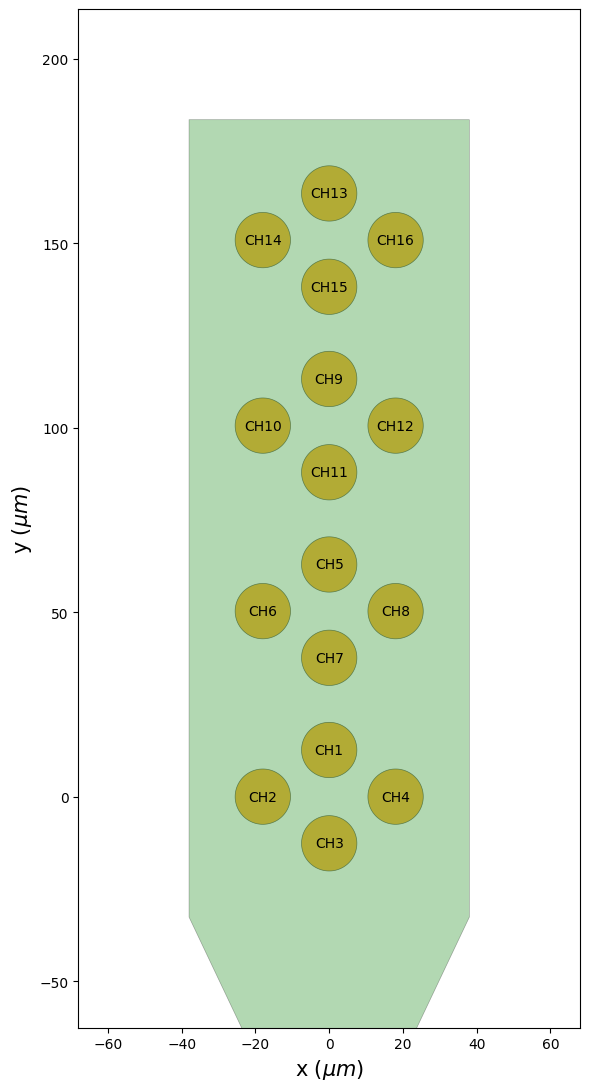

In [5]:
# PROBE SETUP
#
#   1) Geometry already in the file  -> use as-is.
#   2) manual_probe_file provided    -> load probe from file. Supported formats:
#        .json  native probeinterface (read_probeinterface) — wiring already embedded
#        .prb   klusta/spyking-circus legacy (read_prb)     — wiring already embedded
#        .csv   x,y position table (read_csv)               — identity wiring assumed
#        .npy   (n_channels, 2) numpy array                 — identity wiring assumed
#      Prints channel -> position correspondence.
#   3) Nothing provided              -> dummy probe selected by dummy_probe_type:
#        'linear'  - single row, 1000 um spacing (sorter-safe default)
#        'tetrode' - 4-contact clusters (25 um pitch), spaced 300 um apart
#        'grid'    - rectangular 2-D grid at 200 um pitch

import pandas as pd
from probeinterface import Probe, read_probeinterface, read_prb
from probeinterface import read_csv as read_probe_csv

n_ch = raw_rec.get_num_channels()
_original_channel_ids = raw_rec.channel_ids.copy()

# STEP 1: geometry already in the file
_has_geometry = False
try:
    raw_rec.get_probe()
    _has_geometry = True
    print(f'[probe] Geometry already in the file ({n_ch} channels).')
except ValueError:
    print('[probe] No geometry found in the file.')

# STEP 2: load from file
if not _has_geometry and manual_probe_file is not None:
    _fpath = Path(manual_probe_file)
    _ext   = _fpath.suffix.lower()

    if _ext == '.json':
        _probegroup = read_probeinterface(_fpath)
        raw_rec = raw_rec.set_probegroup(_probegroup, group_mode='by_probe')
        print(f'[probe] Loaded native probeinterface JSON ({n_ch} channels, wiring embedded).')
    elif _ext == '.prb':
        _probegroup = read_prb(_fpath)
        raw_rec = raw_rec.set_probegroup(_probegroup, group_mode='by_shank')
        print(f'[probe] Loaded PRB file ({n_ch} channels, wiring embedded).')
    elif _ext == '.csv':
        _probe = read_probe_csv(_fpath)
        _probe.set_device_channel_indices(np.arange(n_ch))
        raw_rec = raw_rec.set_probe(_probe, group_mode='by_probe')
        print(f'[probe] Loaded CSV probe map ({n_ch} channels, identity wiring).')
    elif _ext == '.npy':
        _xy = np.load(_fpath)
        if _xy.shape != (n_ch, 2):
            raise ValueError(f'manual_probe_file has shape {_xy.shape}, expected ({n_ch}, 2)')
        _probe = Probe(ndim=2, si_units='um')
        _probe.set_contacts(positions=_xy, shapes='circle', shape_params={'radius': 7.5})
        _probe.create_auto_shape(probe_type='tip')
        _probe.set_device_channel_indices(np.arange(n_ch))
        raw_rec = raw_rec.set_probe(_probe, group_mode='by_probe')
        print(f'[probe] Loaded NumPy probe map ({n_ch} channels, identity wiring).')
    else:
        raise ValueError(
            f"Unsupported probe file extension '{_ext}'. Use .json, .prb, .csv, or .npy."
        )

    # Print channel -> position correspondence
    _channel_ids = list(raw_rec.channel_ids)
    _probe_xy = raw_rec.get_probe().contact_positions
    print('Channel -> position (x, y) in um:')
    for ch, (x, y) in zip(_channel_ids, _probe_xy):
        print(f'  {ch} -> ({x:.1f}, {y:.1f})')

    _has_geometry = True

# STEP 3: dummy probe (no geometry file provided)
if not _has_geometry:
    if dummy_probe_type == 'tetrode':
        # 4 contacts in a 2x2 cluster per tetrode, tetrodes stacked along y
        _tet_pitch_um   = 25.    # intra-tetrode contact spacing (um)
        _tet_spacing_um = 300.   # centre-to-centre spacing between tetrodes (um)
        _n_tet = int(np.ceil(n_ch / 4))
        _tet_offsets = np.array([[0., 0.], [_tet_pitch_um, 0.],
                                  [0., _tet_pitch_um], [_tet_pitch_um, _tet_pitch_um]])
        _positions = np.vstack([
            _tet_offsets + np.array([0., _t * _tet_spacing_um]) for _t in range(_n_tet)
        ])[:n_ch]
        probe = Probe(ndim=2, si_units='um')
        probe.set_contacts(positions=_positions, shapes='circle', shape_params={'radius': 7.5})
        probe.create_auto_shape(probe_type='tip')
        probe.set_device_channel_indices(np.arange(n_ch))
        raw_rec = raw_rec.set_probe(probe, group_mode='by_probe')
        raw_rec = raw_rec.rename_channels(_original_channel_ids)
        _has_geometry = True
        _n_full = n_ch // 4
        _n_rem  = n_ch % 4
        print(f'[probe] Dummy tetrode: {_n_full} complete tetrode(s)'
              + (f' + 1 partial ({_n_rem} contact(s))' if _n_rem else '')
              + f', {_tet_pitch_um:.0f} um intra-tetrode pitch, '
              + f'{_tet_spacing_um:.0f} um inter-tetrode spacing.')

    elif dummy_probe_type == 'grid':
        # Rectangular 2-D grid — most-square layout for n_ch channels.
        _grid_pitch_um = 200.    # centre-to-centre pitch in x and y (um)
        _n_cols = int(np.ceil(np.sqrt(n_ch)))
        _n_rows = int(np.ceil(n_ch / _n_cols))
        _n_total = _n_rows * _n_cols
        _n_excess = _n_total - n_ch
        _ridx = np.arange(_n_total) // _n_cols
        _cidx = np.arange(_n_total) % _n_cols
        if _n_excess > 0:
            # Corner score: 0 at grid corners, increasing toward centre
            _cs = (np.minimum(_ridx, _n_rows - 1 - _ridx) +
                   np.minimum(_cidx, _n_cols - 1 - _cidx))
            _remove = np.argsort(_cs, kind='stable')[:_n_excess]
            _keep = np.ones(_n_total, dtype=bool)
            _keep[_remove] = False
            _corner_msg = f', {_n_excess} corner/edge slot(s) inactive'
        else:
            _keep = np.ones(_n_total, dtype=bool)
            _corner_msg = ''
        _positions = np.column_stack([_cidx[_keep] * _grid_pitch_um,
                                       _ridx[_keep] * _grid_pitch_um])
        probe = Probe(ndim=2, si_units='um')
        probe.set_contacts(positions=_positions, shapes='square', shape_params={'width': 40.})
        probe.create_auto_shape(probe_type='rect')
        probe.set_device_channel_indices(np.arange(n_ch))
        raw_rec = raw_rec.set_probe(probe, group_mode='by_probe')
        raw_rec = raw_rec.rename_channels(_original_channel_ids)
        _has_geometry = True
        print(f'[probe] Dummy grid: {_n_rows}x{_n_cols} layout{_corner_msg}, '
              f'{_grid_pitch_um:.0f} um pitch ({n_ch} contacts).')

    else:  # 'linear' — original fallback
        _dummy_spacing_um = 1000.
        probe = Probe(ndim=2, si_units='um')
        probe.set_contacts(
            positions=np.column_stack([np.arange(n_ch, dtype=float) * _dummy_spacing_um, np.zeros(n_ch)]),
            shapes='circle', shape_params={'radius': 7.5},
        )
        probe.create_auto_shape(probe_type='tip')
        probe.set_device_channel_indices(np.arange(n_ch))
        raw_rec = raw_rec.set_probe(probe, group_mode='by_probe')
        raw_rec = raw_rec.rename_channels(_original_channel_ids)
        _has_geometry = True
        print(f'[probe] Dummy linear: {n_ch} channels spaced {_dummy_spacing_um:.0f} um apart. '
              f'Set dummy_probe_type to "tetrode" or "grid" for a spatial layout, '
              f'or provide manual_probe_file for real geometry.')

# STEP 4 (optional): remap channel IDs to electrode labels from CSV
# CSV must have columns: 'channel_id' (must match recording channel IDs exactly)
#   and 'electrode_label' (the label to assign to that channel).
# Only channels listed in the CSV are renamed; others keep their original ID.
# Run once with channel_label_csv=None to see your exact channel IDs in the printout below,
#   then build the CSV and re-run with channel_label_csv pointing to it.
_current_ids = list(raw_rec.channel_ids)
if channel_label_csv is None:
    _preview = list(_current_ids[:5])
    _more = f' ... and {len(_current_ids) - 5} more' if len(_current_ids) > 5 else ''
    print(f'[channel map] No CSV provided. Channel IDs sample: {_preview}{_more}')
else:
    _label_df = pd.read_csv(channel_label_csv)
    if 'channel_id' not in _label_df.columns or 'electrode_label' not in _label_df.columns:
        raise ValueError("channel_label_csv must have columns 'channel_id' and 'electrode_label'.")
    _mapping = dict(zip(_label_df['channel_id'].astype(str), _label_df['electrode_label'].astype(str)))
    _new_labels = [_mapping.get(str(ch), str(ch)) for ch in _current_ids]
    _remapped = [(ch, el) for ch, el in zip(_current_ids, _new_labels) if str(ch) != el]
    _unmatched = [str(r) for r in _label_df['channel_id'] if str(r) not in {str(c) for c in _current_ids}]
    print(f'[channel map] Remapped {len(_remapped)} / {len(_current_ids)} channel(s).')
    for ch, el in _remapped:
        print(f'  {ch} -> {el}')
    if _unmatched:
        _more = '...' if len(_unmatched) > 5 else ''
        print(f'  Warning: {len(_unmatched)} CSV channel_id(s) not found in recording: {_unmatched[:5]}{_more}')
    raw_rec = raw_rec.rename_channels(_new_labels)
    print(f'[channel map] Labels applied from {channel_label_csv}')

# Visual check
_label_max_channels = 64
_contact_xy = raw_rec.get_probe().contact_positions
_aspect_h = max(6., min(14., 6. * (_contact_xy[:, 1].ptp() / max(_contact_xy[:, 0].ptp(), 1.)) ** 0.5))
fig, ax = plt.subplots(figsize=(6, _aspect_h))
si.plot_probe_map(raw_rec, with_channel_ids=n_ch <= _label_max_channels, ax=ax)
_margin_um = 50.
ax.set_xlim(_contact_xy[:, 0].min() - _margin_um, _contact_xy[:, 0].max() + _margin_um)
ax.set_ylim(_contact_xy[:, 1].min() - _margin_um, _contact_xy[:, 1].max() + _margin_um)
plt.tight_layout()
plt.show()

In [6]:
# PREPROCESSING
_n_raw_channels = raw_rec.get_num_channels()

if FORMAT == 'spikeglx':
    rec1 = si.phase_shift(raw_rec)
    rec1 = si.highpass_filter(raw_rec, freq_min=freq_min)
else:
    rec1 = si.highpass_filter(raw_rec, freq_min=freq_min)

bad_channel_ids, channel_labels = si.detect_bad_channels(rec1)

rec2 = rec1.remove_channels(bad_channel_ids)

if FORMAT == 'spikeglx':
    rec2 = si.phase_shift(rec2)

rec = si.common_reference(rec2, operator=cref_operator, reference=cref_reference)
print(rec)

# Bad-channel label export (MCS-specific in the original pipeline; harmless for all formats)
_bad_labels = []
for _ch in bad_channel_ids:
    _idx = np.where(rec1.channel_ids == _ch)[0]
    _bad_labels.append(str(channel_labels[_idx[0]]) if len(_idx) > 0 else 'auto')
with open(base_folder / 'bad_channels.csv', 'w') as _f:
    _f.write('channel_id,label\n')
    for _c, _l in zip(bad_channel_ids, _bad_labels):
        _f.write(f'{_c},{_l}\n')
print(f'Bad channels ({len(bad_channel_ids)}) saved -> {base_folder / "bad_channels.csv"}')


CommonReferenceRecording: 16 channels - 30.0kHz - 1 segments - 90,000 samples - 3.00s 
                          int16 dtype - 2.75 MiB
Bad channels (0) saved -> C:\Users\labuser\Ilaria\spikeinterface_pipeline\output\openephys\openephys_output_2min\bad_channels.csv


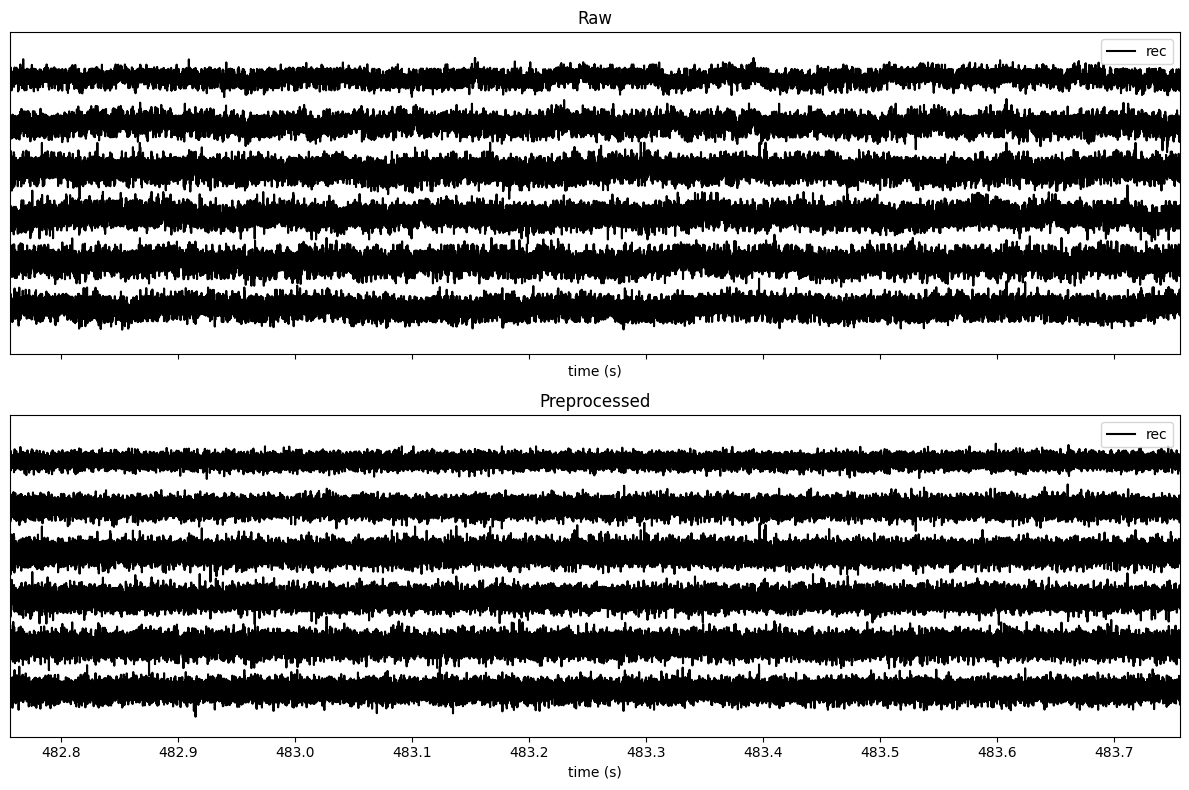

In [7]:
# TRACES VISUALIZATION
import re
_fs    = raw_rec.get_sampling_frequency()
raw_2s = raw_rec.frame_slice(0, int(2 * _fs))
rec_2s = rec.frame_slice(0, int(2 * _fs))

_nat_key     = lambda s: [int(t) if t.isdigit() else t.lower() for t in re.split(r'(\d+)', s)]
_good_ch_ids = [c for c in sorted(raw_rec.channel_ids, key=_nat_key) if c in set(rec.channel_ids)]

fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)
si.plot_traces(raw_2s, channel_ids=_good_ch_ids[:6], mode='line', backend='matplotlib', ax=axes[0])
si.plot_traces(rec_2s, channel_ids=_good_ch_ids[:6], mode='line', backend='matplotlib', ax=axes[1])
axes[0].set_title('Raw')
axes[1].set_title('Preprocessed')
plt.tight_layout()
plt.show()

In [8]:
# SAVE PREPROCESSED RECORDING
import gc, shutil
try: del analyzer
except NameError: pass
try: del rec_analysis
except NameError: pass
try: del raw_rec
except NameError: pass
try: del rec1
except NameError: pass
try: del rec2
except NameError: pass
try: del rec3
except NameError: pass
gc.collect()

163

In [9]:
# Windows fix I needed to add, otherwise the file got locked out and I kept having an error, NOT NEEDED IN FINAL CODE
_pf = base_folder / 'preprocess'
_pf_loaded = False
if _pf.exists():
    try:
        rec = si.load(_pf)
        _pf_loaded = True
        print(f'Loaded existing preprocessed recording (delete {_pf} to force re-saving)')
    except Exception:
        _pf = base_folder / 'preprocess_new'
        shutil.rmtree(_pf, ignore_errors=True)
        print('Existing preprocess folder is locked/corrupt — saving to preprocess_new')
if not _pf_loaded:
    rec = rec.save(folder=_pf, format='binary',
                   overwrite=True, n_jobs=1, chunk_duration='1s', progress_bar=True)
    print(f'Preprocessed recording saved -> {_pf}')

Loaded existing preprocessed recording (delete C:\Users\labuser\Ilaria\spikeinterface_pipeline\output\openephys\openephys_output_2min\preprocess to force re-saving)


## 3 · Sort & analyze

Run the sorter and build a `SortingAnalyzer` with waveforms, templates, and quality metrics.

In [10]:
# SPIKE SORTING
sorting = si.run_sorter(sorter, rec, folder=base_folder / f'{sorter}_output',
                        remove_existing_folder=True, verbose=True)
print(sorting)

write_memory_recording (no parallelization):   0%|          | 0/124 [00:00<?, ?it/s]

noise_level (no parallelization):   0%|          | 0/20 [00:00<?, ?it/s]

detect peaks (locally_exclusive) (no parallelization):   0%|          | 0/124 [00:00<?, ?it/s]

detect_peaks(): 141 peaks found
select_peaks(): 141 peaks kept for clustering


Fit peaks svd (no parallelization):   0%|          | 0/124 [00:00<?, ?it/s]

...

C:\Users\labuser\miniforge3\envs\si_pipeline\lib\site-packages\spikeinterface\postprocessing\template_similarity.py:345: NumbaTypeSafetyWarning: unsafe cast from uint64 to int64. Precision may be lost.
  overlapping_ids = overlapping_j_list[i]


find_clusters_from_peaks(): 5 cluster found


estimate_templates_with_accumulator (no parallelization):   0%|          | 0/124 [00:00<?, ?it/s]

find spikes (tdc-peeler) (no parallelization):   0%|          | 0/124 [00:00<?, ?it/s]

tridesclous2 run time 77.62s
NumpyFolder (NumpyFolderSorting): 5 units - 1 segments - 30.0kHz


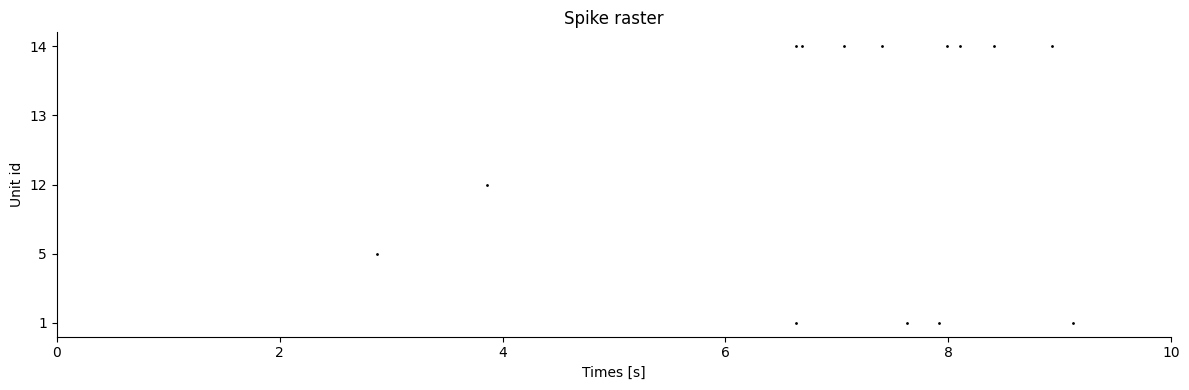

In [11]:
# RASTER PLOT 

fig, ax = plt.subplots(figsize=(12, 4))
si.plot_rasters(sorting, time_range=[0, min(10, rec.get_total_duration())], ax=ax)
ax.set_title('Spike raster')
plt.tight_layout()
plt.show()

In [12]:
# SORTING ANALYZER
si.set_global_job_kwargs(n_jobs=1, chunk_duration='1s', progress_bar=True)

rec_analysis = si.load(_pf)

analyzer = si.create_sorting_analyzer(sorting, rec_analysis, sparse=_analyzer_sparse, format='memory')

analyzer.compute('random_spikes', method='uniform', max_spikes_per_unit=max_spikes_per_unit)
analyzer.compute('waveforms', ms_before=waveform_ms_before, ms_after=waveform_ms_after)
analyzer.compute('templates', operators=['average', 'median', 'std'])
analyzer.compute('noise_levels')
analyzer.compute('correlograms')
analyzer.compute('unit_locations')
analyzer.compute('spike_amplitudes')
analyzer.compute('template_similarity')
analyzer.compute('spike_locations')  

if FORMAT == 'spikeglx':
    analyzer.compute('template_metrics', metric_names=template_metric_names)  

if compute_pca_metrics:
    analyzer.compute('principal_components', n_components=pca_n_components, mode=pca_mode)

print(analyzer)

compute_waveforms (no parallelization):   0%|          | 0/124 [00:00<?, ?it/s]

noise_level (no parallelization):   0%|          | 0/20 [00:00<?, ?it/s]

spike_amplitudes (no parallelization):   0%|          | 0/124 [00:00<?, ?it/s]

spike_locations (no parallelization):   0%|          | 0/124 [00:00<?, ?it/s]

Fitting PCA:   0%|          | 0/5 [00:00<?, ?it/s]

Projecting waveforms:   0%|          | 0/5 [00:00<?, ?it/s]

SortingAnalyzer: 16 channels - 5 units - 1 segments - memory - has recording
Loaded 10 extensions: random_spikes, waveforms, templates, noise_levels, correlograms, unit_locations, spike_amplitudes, template_similarity, spike_locations, principal_components


In [13]:
# QUALITY METRICS
metrics_ext = analyzer.compute('quality_metrics', metric_names=metric_names,
                               metric_params=metric_extension_params)
metrics = metrics_ext.get_data()

# merge in template (waveform-shape) metrics so the exported table matches
# the UnitRefine training_data.csv column set (Neuropixels / spikeglx only)
if FORMAT == 'spikeglx':
    template_metrics = analyzer.get_extension('template_metrics').get_data()
    metrics = metrics.join(template_metrics)

print(metrics)
metrics.to_csv(base_folder / 'quality_metrics.csv')
print(f"Quality metrics saved -> {base_folder / 'quality_metrics.csv'}")

C:\Users\labuser\miniforge3\envs\si_pipeline\lib\site-packages\spikeinterface\metrics\quality\misc_metrics.py:1026: UserWarning: Amplitude cutoff set to NaN for units [1, 5, 12, 13, 14]: too few spikes (< 500).
  warnings.warn(
C:\Users\labuser\miniforge3\envs\si_pipeline\lib\site-packages\spikeinterface\metrics\quality\misc_metrics.py:1323: UserWarning: Drift metrics could not be computed for units [1, 5, 12, 13, 14] because they have less than 2 bins given the specified 'interval_s' and 'min_num_bins' or not enough valid intervals.
  warnings.warn(


    num_spikes  firing_rate  presence_ratio       snr  isi_violations_ratio  \
1          106     0.855973             1.0  3.074332              3.673779   
5           13     0.104978             1.0  4.230889              0.000000   
12          15     0.121128             1.0  4.259935              0.000000   
13          30     0.242256             1.0  2.942137              0.000000   
14          42     0.339159             1.0  3.083897              0.000000   

    isi_violations_count  rp_contamination  rp_violations  \
1                      1               1.0              1   
5                      0               0.0              0   
12                     0               0.0              0   
13                     0               0.0              0   
14                     0               0.0              0   

    sliding_rp_violation  sync_spike_2  ...  amplitude_cv_range  drift_ptp  \
1                    NaN      0.056604  ...                 NaN        NaN   
5 

## 4 · Curate & export

Keep the units that pass the quality thresholds, save the results, and open the interactive viewer.

In [14]:
# QUALITY-BASED FILTERING
_conditions = []
if not metrics['amplitude_cutoff'].isna().all():
    _conditions.append(f"(amplitude_cutoff < {amplitude_cutoff_thresh})")
_conditions.append(f"(isi_violations_ratio < {isi_violations_ratio_thresh})")
if not metrics['presence_ratio'].isna().all():
    _conditions.append(f"(presence_ratio > {presence_ratio_thresh})")
query = " & ".join(_conditions)

keep_unit_ids = np.asarray(metrics.query(query).index.tolist(), dtype=sorting.unit_ids.dtype)
print(f"Keeping {len(keep_unit_ids)} / {len(sorting.unit_ids)} units after quality filtering")
if metrics['amplitude_cutoff'].isna().all():
    print("Note: amplitude_cutoff skipped (all NaN, too few spikes per unit)")
if metrics['presence_ratio'].isna().all():
    print("Note: presence_ratio skipped (all NaN, recording shorter than 60s bin)")

analyzer = analyzer.select_units(keep_unit_ids)

Keeping 4 / 5 units after quality filtering
Note: amplitude_cutoff skipped (all NaN, too few spikes per unit)


In [15]:
if FORMAT == 'spikeglx':
    import spikeinterface.curation as sc

    # Apply the noise/neural model
    noise_neuron_labels = sc.auto_label_units(
        sorting_analyzer=analyzer,
        repo_id="AnoushkaJain3/noise_neural_classifier_lightweight",
        trusted=['numpy.dtype'],
    )

    noise_units = noise_neuron_labels[noise_neuron_labels['prediction'] == 'noise']
    analyzer_neural = analyzer.remove_units(noise_units.index)

    # Apply the sua/mua model
    sua_mua_labels = sc.auto_label_units(
        sorting_analyzer=analyzer_neural,
        repo_id="AnoushkaJain3/sua_mua_classifier_lightweight",
        trusted=['numpy.dtype'],
    )

    all_labels = pd.concat([sua_mua_labels, noise_units]).sort_index()
    print(all_labels)

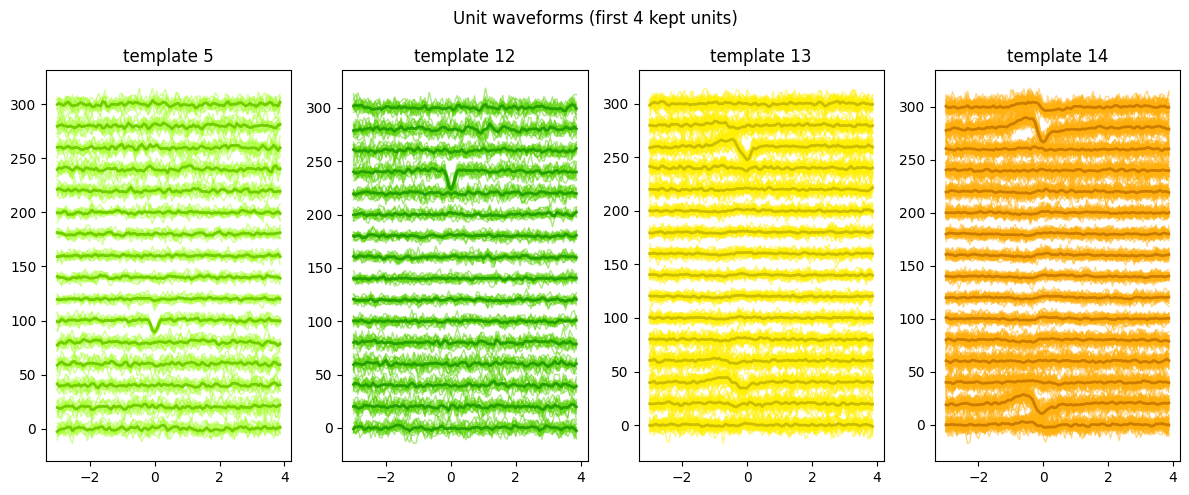

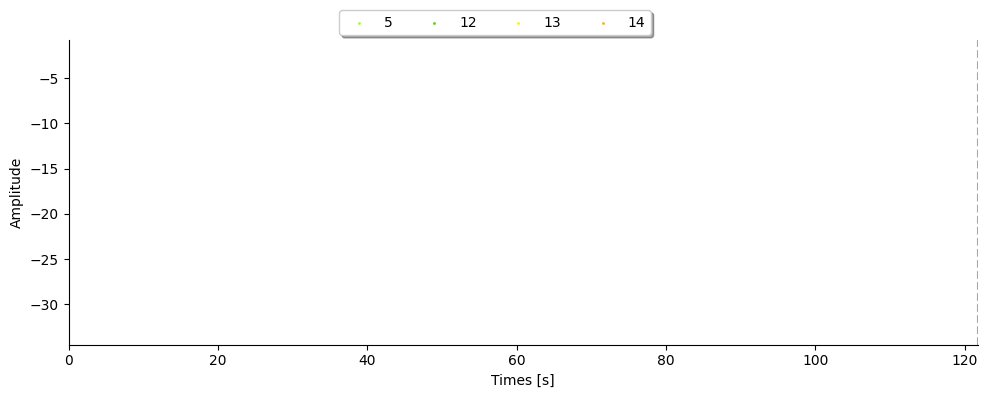

C:\Users\labuser\miniforge3\envs\si_pipeline\lib\site-packages\spikeinterface\widgets\metrics.py:66: UserWarning: Skipping ['sliding_rp_violation', 'amplitude_cutoff', 'amplitude_cv_median', 'amplitude_cv_range', 'drift_ptp', 'drift_std', 'drift_mad', 'l_ratio'] because they contain all NaNs
  warnings.warn(f"Skipping {nan_metrics} because they contain all NaNs")
C:\Users\labuser\AppData\Local\Temp\ipykernel_14412\2758682940.py:25: UserWarning: Tight layout not applied. tight_layout cannot make Axes height small enough to accommodate all Axes decorations.
  plt.tight_layout()


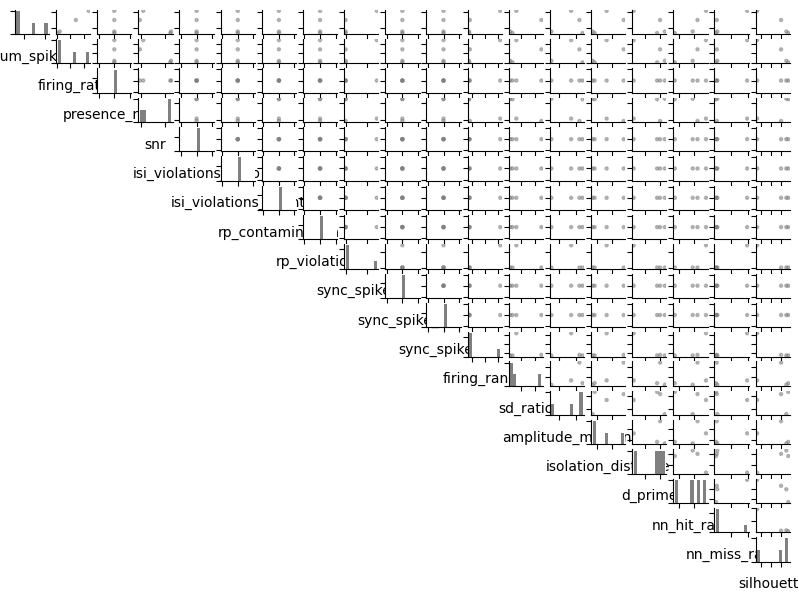

In [16]:
# PER-UNIT DIAGNOSTIC PLOTS 

#needed?? just found on internet

_n_preview = min(6, len(keep_unit_ids))
_preview_units = keep_unit_ids[:_n_preview]

# Waveform shapes 
fig1 = plt.figure(figsize=(3 * _n_preview, 5))
si.plot_unit_waveforms(analyzer, unit_ids=_preview_units, figure=fig1)
plt.suptitle('Unit waveforms (first {} kept units)'.format(_n_preview))
plt.tight_layout()
plt.show()

# Amplitude over time 
fig2, ax2 = plt.subplots(figsize=(10, 4))
si.plot_amplitudes(analyzer, unit_ids=_preview_units, ax=ax2)
ax2.set_title('Spike amplitude over time')
plt.tight_layout()
plt.show()

# Quality metric overview 
fig3 = plt.figure(figsize=(10, 8))
si.plot_quality_metrics(analyzer, figure=fig3)
plt.tight_layout()
plt.show()


In [17]:
# PIPELINE LOG
import json as _json, datetime as _dt

_log = {
    'timestamp':       _dt.datetime.now().isoformat(),
    'si_version':      si.__version__,
    'format':          FORMAT,
    'source_path':     _source_path,
    'sorter':          sorter,
    'n_channels_raw':  int(_n_raw_channels),
    'n_channels_kept': int(rec_analysis.get_num_channels()),
    'bad_channel_ids': [str(c) for c in bad_channel_ids],
    'n_units_sorted':  int(len(sorting.unit_ids)),
    'n_units_kept':    int(len(keep_unit_ids)),
    'parameters': {
        'freq_min':                    freq_min,
        'cref_operator':               cref_operator,
        'cref_reference':              cref_reference,
        'waveform_ms_before':          waveform_ms_before,
        'waveform_ms_after':           waveform_ms_after,
        'max_spikes_per_unit':         max_spikes_per_unit,
        'amplitude_cutoff_thresh':     amplitude_cutoff_thresh,
        'isi_violations_ratio_thresh': isi_violations_ratio_thresh,
        'presence_ratio_thresh':       presence_ratio_thresh,
    },
}
_log_path = base_folder / 'pipeline_run_log.json'
_log_path.write_text(_json.dumps(_log, indent=2))
print(f'Run log -> {_log_path}')

Run log -> C:\Users\labuser\Ilaria\spikeinterface_pipeline\output\openephys\openephys_output_2min\pipeline_run_log.json


In [18]:
# SAVE ANALYZER
import shutil
_analyzer_folder = base_folder / 'analyzer'
if _analyzer_folder.exists():
    shutil.rmtree(_analyzer_folder)
analyzer.save_as(folder=_analyzer_folder, format='binary_folder')

C:\Users\labuser\miniforge3\envs\si_pipeline\lib\site-packages\spikeinterface\core\basesorting.py:384: UserWarning: The registered recording will not be persistent on disk, but only available in memory
  warnings.warn("The registered recording will not be persistent on disk, but only available in memory")


SortingAnalyzer: 16 channels - 4 units - 1 segments - binary_folder - has recording
Loaded 11 extensions: random_spikes, waveforms, templates, noise_levels, correlograms, unit_locations, spike_amplitudes, template_similarity, spike_locations, principal_components, quality_metrics

In [19]:
# INTERACTIVE VIEWER (sigui)

import spikeinterface_gui
spikeinterface_gui.run_mainwindow(analyzer)